# Predizione del vincitore di una partita di tennis con CatBoost

## Obiettivo

Il problema e' una **classificazione binaria**:

- classe `1`: vince il giocatore A;
- classe `0`: vince il giocatore B.

L'obiettivo e' addestrare un classificatore CatBoost e verificare se riesce a
generalizzare sulle partite disputate dopo quelle usate per l'addestramento.

## Perche' CatBoost?

CatBoost e' un **metodo ensemble basato sul boosting**. Come in AdaBoost, il
boosting combina in sequenza diversi alberi decisionali: ogni nuovo albero
cerca di ridurre gli errori dell'ensemble corrente.

La previsione finale combina il contributo di tutti gli alberi. CatBoost e'
adatto perche' il dataset contiene attributi numerici e categorici, come
superficie, campo e torneo.

## Configurazione

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    brier_score_loss,
    classification_report,
    log_loss,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "scripts" / "models"
sys.path.insert(0, str(MODELS_DIR))

from train_catboost import chronological_split, prepare_catboost_features  # noqa: E402

FEATURES_PATH = PROJECT_ROOT / "data/interim/tennis_matches_features.data"
METADATA_PATH = PROJECT_ROOT / "data/interim/tennis_matches_features_metadata.json"
METRICS_PATH = PROJECT_ROOT / "data/interim/catboost_metrics.json"
MODEL_PATH = PROJECT_ROOT / "data/interim/catboost_model.cbm"

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Caricamento del dataset

In [2]:
dataset = pd.read_csv(FEATURES_PATH)
dataset["date"] = pd.to_datetime(dataset["date"], errors="raise")

metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
training_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))

columns_to_show = [
    "date",
    "surface",
    "winner_rank",
    "loser_rank",
    "rank_diff",
    "win_rate_diff",
    "implied_prob_diff_avg",
    "player_a_win",
]

print("Dimensioni del dataset:", dataset.shape)
display(dataset[columns_to_show].head())
display(dataset["player_a_win"].value_counts().sort_index().rename("istanze").to_frame())

Dimensioni del dataset: (30952, 115)


,date,surface,winner_rank,loser_rank,rank_diff,win_rate_diff,implied_prob_diff_avg,player_a_win
0,2020-01-06,Hard,76.0,58.0,-18.0,NaN,-0.013926,0
1,2020-01-06,Hard,58.0,76.0,18.0,NaN,0.013926,1
2,2020-01-06,Hard,43.0,55.0,12.0,NaN,0.107462,0
3,2020-01-06,Hard,55.0,43.0,-12.0,NaN,-0.107462,1
4,2020-01-06,Hard,83.0,54.0,-29.0,NaN,-0.248736,0


,istanze
player_a_win,
0,15476
1,15476


Il dataset contiene due righe per ogni partita reale, una per ciascun
orientamento dei giocatori. In questo modo la variabile obiettivo e' bilanciata
e il modello non dipende dall'ordine originale vincitore/sconfitto.

Sono usate solo informazioni disponibili prima della partita: ranking,
risultati precedenti, rendimento sulla superficie, scontri diretti,
statistiche dei giocatori e probabilita' di mercato.

## 2. Preparazione delle feature e divisione train/test

Una divisione casuale non e' appropriata: potrebbe addestrare il modello
su partite future e valutarlo su partite precedenti.

Il 15% piu' recente delle date uniche e' quindi riservato come **test set**.
Le partite precedenti costituiscono il **training set**. I due orientamenti
della stessa partita condividono la data e restano nella stessa partizione.

In [3]:
numeric_features = tuple(metadata["numeric_features"])
categorical_features = tuple(metadata["categorical_features"])
feature_names = numeric_features + categorical_features

X = prepare_catboost_features(
    dataset.loc[:, feature_names],
    numeric_features,
    categorical_features,
)
y = dataset["player_a_win"].astype(int)

train_mask, test_mask = chronological_split(dataset)
train_index = np.flatnonzero(train_mask)
test_index = np.flatnonzero(test_mask)
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

split = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "prima data": [
            dataset.iloc[train_index]["date"].min().date(),
            dataset.iloc[test_index]["date"].min().date(),
        ],
        "ultima data": [
            dataset.iloc[train_index]["date"].max().date(),
            dataset.iloc[test_index]["date"].max().date(),
        ],
    },
    index=["addestramento", "test"],
)
display(split)

,rows,prima data,ultima data
addestramento,26472,2020-01-06,2025-08-07
test,4480,2025-08-08,2026-07-12


## 3. Baseline ingenua

Il classificatore va confrontato con una baseline semplice, che predice
sempre la classe maggioritaria.

Poiche' il dataset simmetrico e' bilanciato, l'accuratezza attesa della baseline
e' circa il 50%.

In [4]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, baseline.predict(X_test))

print(f"Accuratezza della baseline ingenua: {baseline_accuracy:.4f}")

Accuratezza della baseline ingenua: 0.5000


## 4. Parametri fissi del modello

Il trainer usa parametri fissi: 300 alberi, profondita' 8,
learning rate 0.03, regolarizzazione L2 pari a 3 e seed 42.
Questa esecuzione non usa cross-validation, ricerca dei parametri o early stopping.

In [5]:
model = CatBoostClassifier()
model.load_model(str(MODEL_PATH))
display(pd.Series(model.get_params(), name="parameters").to_frame())

,parameters
allow_writing_files,False
verbose,0
iterations,300
loss_function,Logloss
l2_leaf_reg,3
depth,8
random_seed,42
learning_rate,0.03


## 5. Caricamento del modello addestrato

Eseguire `python scripts/models/train_catboost.py` dalla radice del
progetto prima del notebook. Il trainer esegue `model.fit(X_train, y_train)`
e salva il modello. Il notebook valuta il modello salvato e verifica i risultati
rispetto alle metriche di training.

## 6. Valutazione del classificatore

In [6]:
train_prediction = model.predict(X_train).astype(int).ravel()
test_probability = model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)

train_accuracy = accuracy_score(y_train, train_prediction)
test_accuracy = accuracy_score(y_test, test_prediction)
test_auc = roc_auc_score(y_test, test_probability)
test_log_loss = log_loss(y_test, test_probability)
test_brier_score = brier_score_loss(y_test, test_probability)
assert np.isclose(test_accuracy, training_metrics["holdout_accuracy"])
assert np.isclose(test_auc, training_metrics["holdout_roc_auc"])
market_probability = dataset.iloc[test_index]["winner_market_prob_normalized"]
market_valid = market_probability.notna()
market_y = y_test.loc[market_valid]
market_probability = market_probability.loc[market_valid]
market_metrics = {
    "accuracy": accuracy_score(market_y, market_probability >= 0.5),
    "roc_auc": roc_auc_score(market_y, market_probability),
    "log_loss": log_loss(market_y, market_probability),
    "brier_score": brier_score_loss(market_y, market_probability),
}
print(f"Copertura della baseline di mercato: {market_valid.mean():.1%}")
results = pd.DataFrame(
    {
        "Accuratezza": [baseline_accuracy, test_accuracy, market_metrics["accuracy"]],
        "ROC AUC": [np.nan, test_auc, market_metrics["roc_auc"]],
        "Log loss": [np.nan, test_log_loss, market_metrics["log_loss"]],
        "Brier score": [np.nan, test_brier_score, market_metrics["brier_score"]],
    },
    index=["Baseline ingenua", "Holdout CatBoost", "Baseline di mercato"],
)
display(results)
print(f"Accuratezza training: {train_accuracy:.4f}")
print("Metriche del modello salvato verificate.")

Copertura della baseline di mercato: 100.0%


,Accuratezza,ROC AUC,Log loss,Brier score
Baseline ingenua,0.500000,NaN,NaN,NaN
Holdout CatBoost,0.694643,0.755905,0.583378,0.200344
Baseline di mercato,0.691518,0.757795,0.581768,0.199607


Accuratezza training: 0.7062
Metriche del modello salvato verificate.


### Sintesi della valutazione

L'accuracy misura quante classi sono previste correttamente alla soglia 0,5;
la ROC AUC misura la qualita' dell'ordinamento delle probabilita'; log loss e
Brier score valutano la qualita' delle probabilita' e sono migliori quando
sono piu' bassi.

- CatBoost raggiunge **0.6946 di accuracy**, 0.1946 sopra la baseline
  maggioritaria e soltanto 0.0031 sopra la baseline di mercato normalizzata.
- Il mercato resta leggermente migliore per ROC AUC (0.7578 contro 0.7559),
  log loss (0.5818 contro 0.5834) e Brier score (0.1996 contro 0.2003).
- L'accuracy di training e' 0.7062, con un divario contenuto di 0.0116 rispetto
  all'holdout.
- Precision, recall e F1-score sono vicini a 0.69 per entrambe le classi: non
  emerge quindi uno squilibrio rilevante tra gli orientamenti dei giocatori.

Il modello supera chiaramente un classificatore ingenuo, ma il confronto misto
con il mercato e il riuso dell'holdout non dimostrano un vantaggio affidabile
sul mercato ne' la generalizzazione futura.

### Matrice di confusione

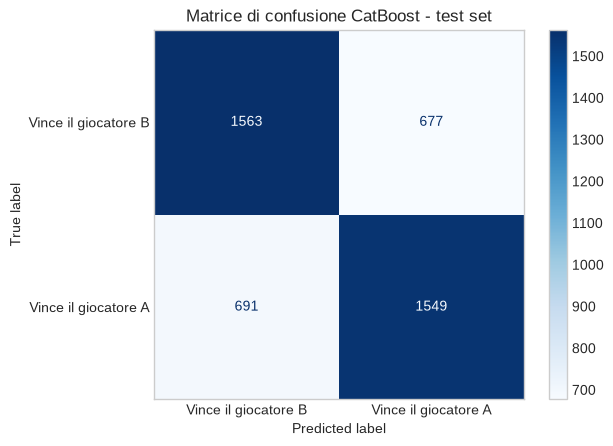

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=["Vince il giocatore B", "Vince il giocatore A"],
    cmap="Blues",
)
plt.title("Matrice di confusione CatBoost - test set")
plt.grid(False)
plt.show()

### Precisione, richiamo e F1-score

In [8]:
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=["Vince il giocatore B", "Vince il giocatore A"],
        digits=4,
    )
)

                      precision    recall  f1-score   support

Vince il giocatore B     0.6934    0.6978    0.6956      2240
Vince il giocatore A     0.6959    0.6915    0.6937      2240

            accuracy                         0.6946      4480
           macro avg     0.6947    0.6946    0.6946      4480
        weighted avg     0.6947    0.6946    0.6946      4480



### Curva ROC

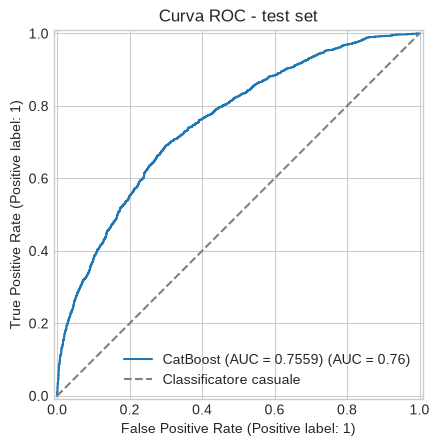

In [9]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probability,
    name=f"CatBoost (AUC = {test_auc:.4f})",
)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Classificatore casuale")
plt.title("Curva ROC - test set")
plt.legend()
plt.show()

## 7. Importanza delle feature

I modelli basati su alberi espongono un punteggio di importanza delle
feature, che indica quanto ciascuna contribuisce alle decisioni dell'ensemble.
L'importanza aiuta a interpretare il modello, ma non dimostra un rapporto
causale.

,importance
implied_prob_diff_avg,6.874215
normalized_market_prob_diff,6.813603
winner_market_prob_normalized,6.214114
loser_market_prob_normalized,5.677338
loser_implied_prob_avg,5.610938
winner_implied_prob_avg,4.776706
market_overround_avg,3.279031
smoothed_surface_diff,2.150686
surface_win_rate_diff,1.868515
log_points_diff,1.865743


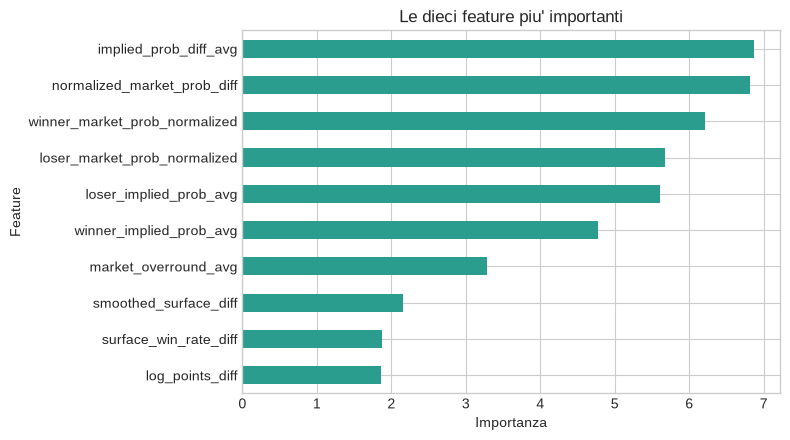

In [10]:
feature_importance = (
    pd.Series(
        model.get_feature_importance(
            Pool(X_train, y_train, cat_features=categorical_features)
        ),
        index=feature_names,
        name="importance",
    )
    .sort_values(ascending=False)
)

assert np.isfinite(feature_importance).all()
assert feature_importance.sum() > 0
display(feature_importance.head(10).to_frame())

ax = feature_importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 4.5),
    color="#2a9d8f",
)
ax.set_title("Le dieci feature piu' importanti")
ax.set_xlabel("Importanza")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 8. Analisi delle partite piu' facili e piu' difficili

Le righe sono abbinate tramite `match_id_internal`, quindi ogni partita
reale viene contata una sola volta solo per questa diagnostica; le metriche
principali valutano le predizioni originali per riga, come il trainer. La confidenza assegnata al vincitore reale
e' mediata tra i due orientamenti. Le previsioni piu' corrette assegnano la
probabilita' maggiore al vincitore reale; quelle piu' errate la minore.

In [11]:
holdout = dataset.iloc[test_index].copy()
holdout["actual_winner_probability"] = np.where(
    y_test.eq(1), test_probability, 1 - test_probability
)
holdout["actual_winner_probability"] = holdout.groupby("match_id_internal")[
    "actual_winner_probability"
].transform("mean")

pair_sizes = holdout.groupby("match_id_internal").size()
assert pair_sizes.eq(2).all(), "Ogni partita di holdout deve avere due orientamenti."

match_diagnostics = (
    holdout.loc[holdout["player_a_win"].eq(1)]
    .set_index("match_id_internal")
)
match_diagnostics["correct"] = (
    match_diagnostics["actual_winner_probability"] >= 0.5
)
match_diagnostics["predicted_winner"] = np.where(
    match_diagnostics["correct"],
    match_diagnostics["winner_name"],
    match_diagnostics["loser_name"],
)

assert len(match_diagnostics) * 2 == len(holdout)
print(f"Partite reali nell'holdout: {len(match_diagnostics):,}")
print(f"Accuratezza per partita: {match_diagnostics['correct'].mean():.4f}")

Partite reali nell'holdout: 2,240
Accuratezza per partita: 0.6915


### Previsioni corrette con maggiore confidenza

In [12]:
instance_columns = [
    "date",
    "winner_name",
    "loser_name",
    "predicted_winner",
    "surface",
    "round",
    "series",
    "winner_rank",
    "loser_rank",
    "normalized_market_prob_diff",
    "actual_winner_probability",
]

most_correct = match_diagnostics.nlargest(
    10, "actual_winner_probability"
)[instance_columns]
display(most_correct)

,date,winner_name,loser_name,predicted_winner,surface,round,series,winner_rank,loser_rank,normalized_market_prob_diff,actual_winner_probability
match_id_internal,,,,,,,,,,,
14041,2026-01-18,Alcaraz C.,Walton A.,Alcaraz C.,Hard,1st Round,GrandSlam,1.0,81.0,0.919426,0.963007
13534,2025-09-25,Alcaraz C.,Baez S.,Alcaraz C.,Hard,1st Round,ATP500,1.0,41.0,0.893008,0.956461
13887,2025-11-04,Hanfmann Y.,Ivanov I.,Hanfmann Y.,Hard,1st Round,ATP250,117.0,935.0,0.819728,0.956392
14128,2026-01-22,Sinner J.,Duckworth J.,Sinner J.,Hard,2nd Round,GrandSlam,2.0,88.0,0.912781,0.954296
13679,2025-10-13,Diallo G.,Omarkhanov A.,Diallo G.,Hard,1st Round,ATP250,35.0,1137.0,0.880841,0.954202
14868,2026-04-24,Sinner J.,Bonzi B.,Sinner J.,Clay,2nd Round,Masters1000,1.0,104.0,0.922842,0.952056
15375,2026-06-29,Sinner J.,Kecmanovic M.,Sinner J.,Grass,1st Round,GrandSlam,1.0,50.0,0.897306,0.950985
13433,2025-08-28,Alcaraz C.,Bellucci M.,Alcaraz C.,Hard,2nd Round,GrandSlam,2.0,65.0,0.871698,0.950577
13476,2025-09-06,Sinner J.,Auger-Aliassime F.,Sinner J.,Hard,Semifinals,GrandSlam,1.0,27.0,0.857044,0.950257


### Previsioni errate con maggiore confidenza

In [13]:
most_wrong = match_diagnostics.nsmallest(
    10, "actual_winner_probability"
)[instance_columns]
display(most_wrong)

,date,winner_name,loser_name,predicted_winner,surface,round,series,winner_rank,loser_rank,normalized_market_prob_diff,actual_winner_probability
match_id_internal,,,,,,,,,,,
15145,2026-05-28,Cerundolo J.M.,Sinner J.,Sinner J.,Clay,2nd Round,GrandSlam,56.0,1.0,-0.917585,0.051573
13833,2025-10-28,Norrie C.,Alcaraz C.,Alcaraz C.,Hard,2nd Round,Masters1000,31.0,1.0,-0.818809,0.053041
14635,2026-03-30,Bennani K.,Halys Q.,Halys Q.,Clay,1st Round,ATP250,731.0,90.0,-0.805014,0.064482
14634,2026-03-30,Baadi T.,Vukic A.,Vukic A.,Clay,1st Round,ATP250,587.0,84.0,-0.768398,0.069704
14159,2026-01-30,Djokovic N.,Sinner J.,Sinner J.,Hard,Semifinals,GrandSlam,4.0,2.0,-0.779381,0.082165
14382,2026-02-24,Kypson P.,De Minaur A.,De Minaur A.,Hard,1st Round,ATP500,103.0,6.0,-0.785208,0.090184
15126,2026-05-26,Walton A.,Medvedev D.,Medvedev D.,Clay,1st Round,GrandSlam,97.0,8.0,-0.845577,0.093540
13900,2025-11-05,Sachko V.,Bublik A.,Bublik A.,Hard,2nd Round,ATP250,222.0,13.0,-0.692308,0.103368
15169,2026-05-30,Svajda Z.,Cerundolo F.,Cerundolo F.,Clay,3rd Round,GrandSlam,85.0,26.0,-0.756818,0.120437


### Distribuzioni numeriche: previsioni corrette ed errate

Per ogni feature numerica, la tabella confronta mediane, tassi di valori
mancanti e differenza tra le medie espressa in deviazioni standard complessive.
Le differenze assolute maggiori mostrano dove gli errori occupano una parte
diversa della distribuzione, senza implicare causalita'.

,feature,wrong_minus_correct_sd,correct_median,wrong_median,correct_missing_rate,wrong_missing_rate,absolute_shift,missing_rate_delta
15,winner_implied_prob_avg,-1.736954,0.719424,0.404858,0.000000,0.000000,1.736954,0.000000
17,implied_prob_diff_avg,-1.734232,0.378128,-0.250369,0.000000,0.000000,1.734232,0.000000
16,loser_implied_prob_avg,1.731205,0.341297,0.653595,0.000000,0.000000,1.731205,0.000000
39,normalized_market_prob_diff,-1.731102,0.355140,-0.236908,0.000000,0.000000,1.731102,0.000000
38,loser_market_prob_normalized,1.731102,0.322430,0.618454,0.000000,0.000000,1.731102,0.000000
37,winner_market_prob_normalized,-1.731102,0.677570,0.381546,0.000000,0.000000,1.731102,0.000000
68,elo_diff,-1.261641,122.614179,-77.901166,0.000000,0.000000,1.261641,0.000000
41,log_rank_diff,-1.203744,0.980829,-0.550046,0.000646,0.002894,1.203744,0.002249
71,surface_elo_diff,-1.186986,96.580179,-59.014933,0.000000,0.000000,1.186986,0.000000
43,log_points_diff,-1.174737,0.798589,-0.414978,0.000646,0.002894,1.174737,0.002249


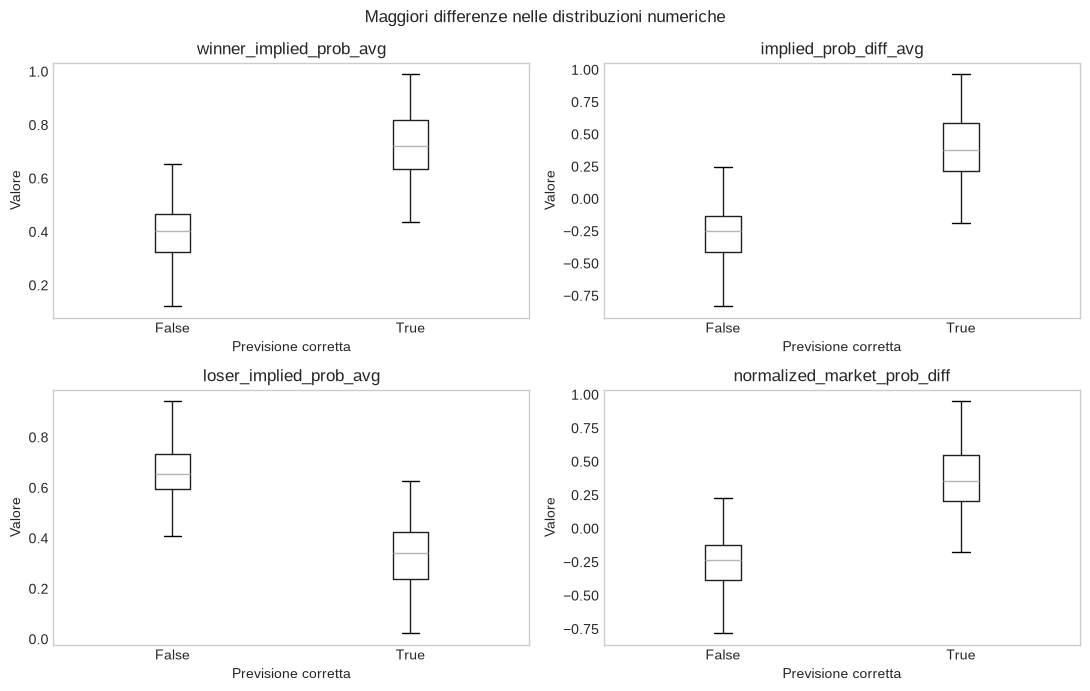

In [14]:
distribution_rows = []
for feature in numeric_features:
    correct_values = pd.to_numeric(
        match_diagnostics.loc[match_diagnostics["correct"], feature],
        errors="coerce",
    )
    wrong_values = pd.to_numeric(
        match_diagnostics.loc[~match_diagnostics["correct"], feature],
        errors="coerce",
    )
    overall_std = pd.to_numeric(
        match_diagnostics[feature], errors="coerce"
    ).std()
    standardized_shift = (
        (wrong_values.mean() - correct_values.mean()) / overall_std
        if overall_std > 0
        else np.nan
    )
    distribution_rows.append(
        {
            "feature": feature,
            "wrong_minus_correct_sd": standardized_shift,
            "correct_median": correct_values.median(),
            "wrong_median": wrong_values.median(),
            "correct_missing_rate": correct_values.isna().mean(),
            "wrong_missing_rate": wrong_values.isna().mean(),
        }
    )

numeric_distribution_shift = (
    pd.DataFrame(distribution_rows)
    .assign(
        absolute_shift=lambda frame: frame["wrong_minus_correct_sd"].abs(),
        missing_rate_delta=lambda frame: (
            frame["wrong_missing_rate"] - frame["correct_missing_rate"]
        ),
    )
    .sort_values("absolute_shift", ascending=False)
)
display(numeric_distribution_shift.head(15))

top_shift_features = numeric_distribution_shift.head(4)["feature"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for feature, axis in zip(top_shift_features, axes.ravel(), strict=True):
    match_diagnostics.boxplot(
        column=feature,
        by="correct",
        ax=axis,
        showfliers=False,
        grid=False,
    )
    axis.set_title(feature)
    axis.set_xlabel("Previsione corretta")
    axis.set_ylabel("Valore")
plt.suptitle("Maggiori differenze nelle distribuzioni numeriche")
plt.tight_layout()
plt.show()

### Quali peculiarita' emergono?

In [16]:
odds_importance_share = feature_importance.loc[
    [
        "winner_implied_prob_avg",
        "loser_implied_prob_avg",
        "implied_prob_diff_avg",
        "winner_market_prob_normalized",
        "loser_market_prob_normalized",
        "normalized_market_prob_diff",
    ]
].sum() / feature_importance.sum()
wrong_matches = match_diagnostics.loc[~match_diagnostics["correct"]]
upset_share = wrong_matches["normalized_market_prob_diff"].lt(0).mean()
largest_missing_gap = numeric_distribution_shift["missing_rate_delta"].abs().max()

print(f"Importanza assegnata alle sei feature delle quote: {odds_importance_share:.1%}")
print(f"Errori in cui il vincitore reale era sfavorito dal mercato: {upset_share:.1%}")
print(f"Massima differenza nel tasso di valori mancanti: {largest_missing_gap:.1%}")
print(
    "Interpretazione: gli errori sono soprattutto vere sorprese. Ranking, Elo, forma e "
    "differenze nelle probabilita' di mercato cambiano segno nel gruppo degli errori. "
    "Non emerge un'anomalia altrettanto grande nei dati mancanti. Le differenze tra "
    "categorie vanno interpretate con cautela perche' molti gruppi sono piccoli."
)

Importanza assegnata alle sei feature delle quote: 36.0%
Errori in cui il vincitore reale era sfavorito dal mercato: 94.5%
Massima differenza nel tasso di valori mancanti: 4.2%
Interpretazione: gli errori sono soprattutto vere sorprese. Ranking, Elo, forma e differenze nelle probabilita' di mercato cambiano segno nel gruppo degli errori. Non emerge un'anomalia altrettanto grande nei dati mancanti. Le differenze tra categorie vanno interpretate con cautela perche' molti gruppi sono piccoli.


## Conclusioni

- CatBoost apprende un segnale predittivo utile e migliora chiaramente rispetto
  alla baseline maggioritaria del 50%.
- Il vantaggio sulle probabilita' di mercato normalizzate non e' convincente:
  l'accuracy e' leggermente superiore, mentre ROC AUC, log loss e Brier score
  sono leggermente peggiori.
- Le probabilita' implicite di mercato rappresentano il 36.0% dell'importanza
  delle feature: una parte sostanziale del segnale e' gia' presente nelle quote.
- Il 94.5% degli errori a livello di partita riguarda sorprese in cui il
  vincitore reale era sfavorito dal mercato; le differenze nei dati mancanti
  sono invece contenute.
- Il piccolo divario tra training e holdout non mostra un overfitting evidente,
  ma i parametri fissi e il riuso dell'holdout limitano questa conclusione.

CatBoost e' quindi una baseline predittiva valida, non la prova di un sistema
capace di battere il mercato. Il tuning deve usare fold cronologici limitati al
training; il modello selezionato va poi valutato una sola volta su un nuovo test
cronologico.